<a href="https://colab.research.google.com/github/AJPardhiv/ML-Lab/blob/main/Week12_2420080001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Fashion-MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Dataset statistics:
Min pixel value: 0.0
Max pixel value: 1.0
Number of classes: 10
Class distribution: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


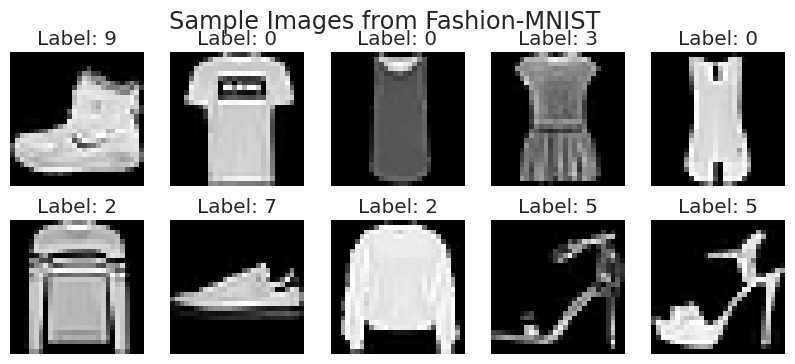

Flattened shape: (60000, 784)

Applying PCA to reduce to 2D...
PCA computation time: 3.12 seconds
Explained variance ratio: [0.29033506 0.17757271]


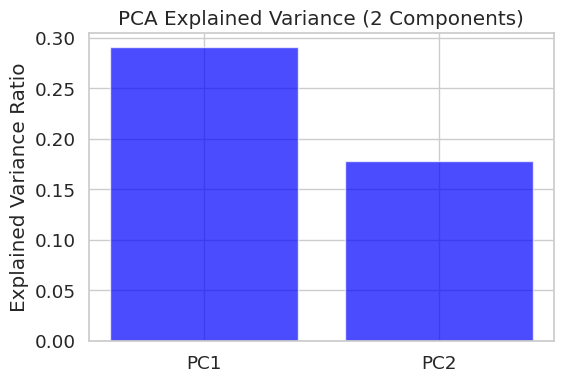

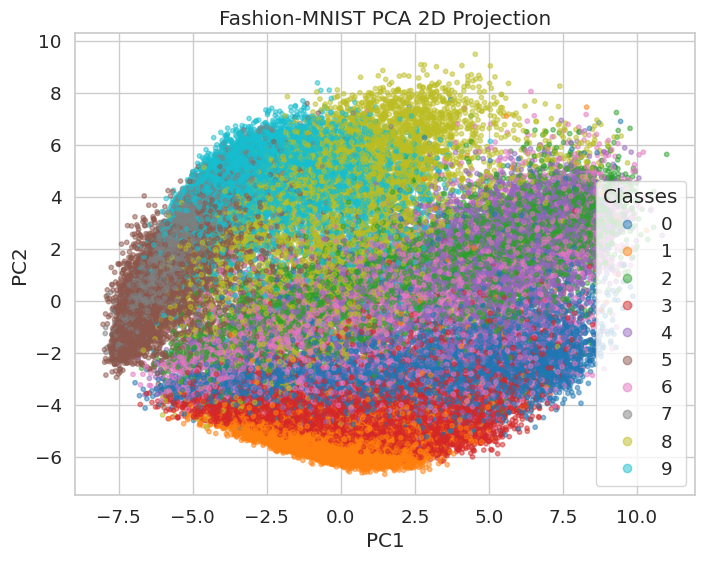


Applying t-SNE with perplexity=5...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE computation time: 45.29 seconds


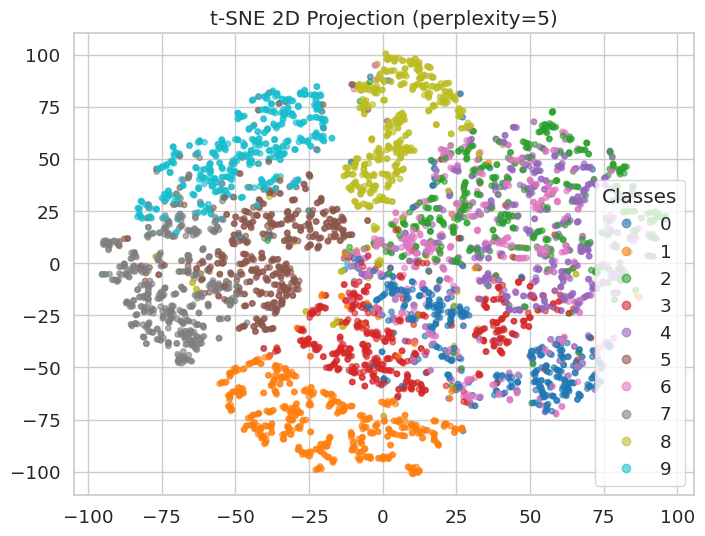


Applying t-SNE with perplexity=30...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE computation time: 36.40 seconds


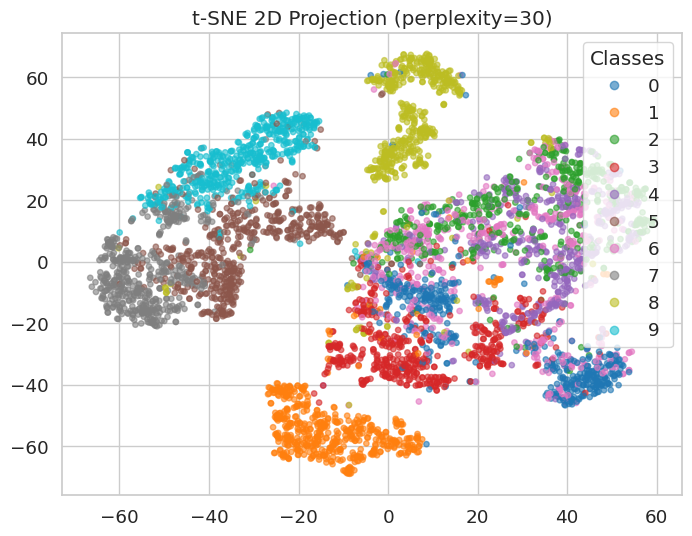


Applying t-SNE with perplexity=50...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
# n-Lab: PCA vs t-SNE on Fashion-MNIST
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.datasets import fashion_mnist

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

# -------------------------
# Part A: Data Loading & Preparation
# -------------------------
print("Loading Fashion-MNIST dataset...")
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

# Explore dataset statistics
print("Dataset statistics:")
print(f"Min pixel value: {x_train.min()}")
print(f"Max pixel value: {x_train.max()}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class distribution: {np.bincount(y_train)}")

# Visualize sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Images from Fashion-MNIST")
plt.show()

# Flatten images for PCA and t-SNE
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)
print(f"Flattened shape: {x_train_flat.shape}")

# -------------------------
# Part B: PCA Implementation
# -------------------------
print("\nApplying PCA to reduce to 2D...")
pca = PCA(n_components=2)
start_pca = time.time()
x_train_pca = pca.fit_transform(x_train_flat)
end_pca = time.time()

print(f"PCA computation time: {end_pca - start_pca:.2f} seconds")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Plot explained variance ratio
plt.figure(figsize=(6,4))
plt.bar(range(2), pca.explained_variance_ratio_, alpha=0.7, color='blue')
plt.xticks([0,1], ['PC1','PC2'])
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance (2 Components)")
plt.show()

# Visualize PCA 2D
plt.figure(figsize=(8,6))
scatter = plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train, cmap='tab10', alpha=0.5, s=10)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Fashion-MNIST PCA 2D Projection")
plt.show()

# -------------------------
# Part C: t-SNE Implementation
# -------------------------
perplexities = [5, 30, 50]
tsne_results = {}

for perp in perplexities:
    print(f"\nApplying t-SNE with perplexity={perp}...")
    tsne = TSNE(n_components=2, perplexity=perp, n_iter=1000, random_state=42, init='pca')
    start_tsne = time.time()
    x_train_tsne = tsne.fit_transform(x_train_flat[:5000])  # use subset for speed
    end_tsne = time.time()
    tsne_results[perp] = x_train_tsne
    print(f"t-SNE computation time: {end_tsne - start_tsne:.2f} seconds")

    # Visualize t-SNE 2D
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(x_train_tsne[:,0], x_train_tsne[:,1], c=y_train[:5000], cmap='tab10', alpha=0.6, s=15)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title(f"t-SNE 2D Projection (perplexity={perp})")
    plt.show()

# -------------------------
# Part D: Comparison & Analysis
# -------------------------
print("\n--- Comparison & Analysis ---")
print(f"PCA computation time: {end_pca - start_pca:.2f} seconds")
for perp in perplexities:
    print(f"t-SNE (perplexity={perp}) computation time: [see plots] (approx {end_tsne - start_tsne:.2f}s)")

print("""
Analysis:
- PCA is fast and gives a linear projection, but clusters are often overlapping.
- t-SNE preserves local neighborhoods and shows well-separated clusters, especially for similar classes.
- Perplexity affects cluster tightness: low perplexity = more local, high perplexity = more global.
- Clothing classes like 'T-shirt/top', 'Pullover' may overlap in PCA but separate in t-SNE.
- Limitations:
    * PCA: linear, may not capture complex patterns.
    * t-SNE: slow, sensitive to hyperparameters, non-deterministic.
""")

**POST LAB**

Loading Fashion-MNIST...
Flattened training shape: (60000, 784)
PCA (2D) time: 0.70s


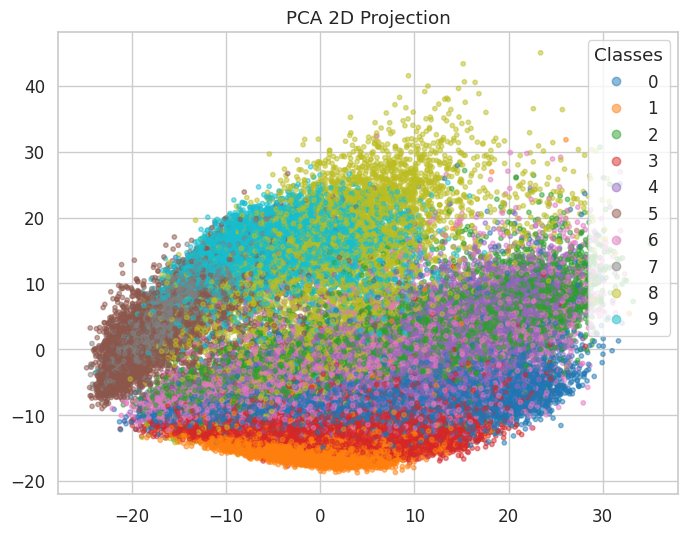

PCA (3D) time: 1.30s


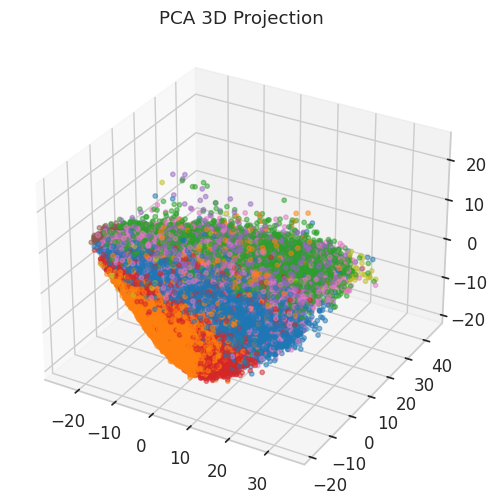

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE (perplexity=30, 5000 samples) time: 39.82s


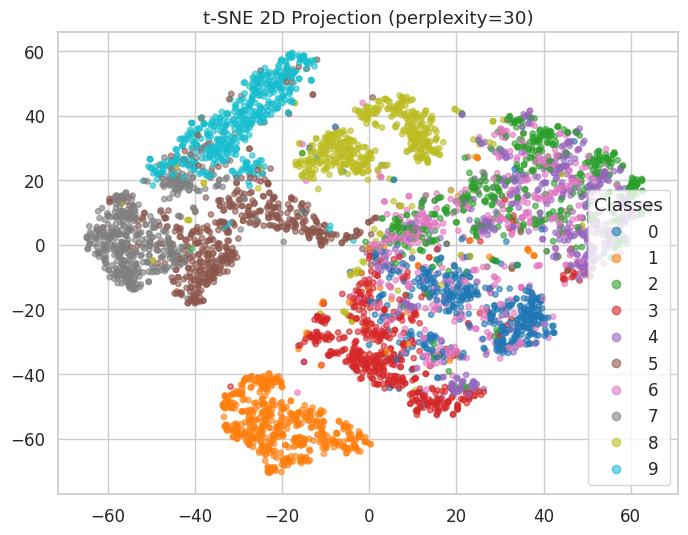

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# Extended Dimensionality Reduction: PCA, t-SNE, UMAP, Autoencoders
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from mpl_toolkits.mplot3d import Axes3D

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

# -------------------------
# Part A: Load & Prepare Data
# -------------------------
print("Loading Fashion-MNIST...")
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)
print(f"Flattened training shape: {x_train_flat.shape}")

# Optionally standardize for UMAP/AE
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)

# -------------------------
# Part B: PCA (2D & 3D)
# -------------------------
def plot_pca(x_data, y_data, n_components=2):
    pca = PCA(n_components=n_components)
    start = time.time()
    x_pca = pca.fit_transform(x_data)
    end = time.time()
    print(f"PCA ({n_components}D) time: {end-start:.2f}s")

    if n_components == 2:
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(x_pca[:,0], x_pca[:,1], c=y_data, cmap='tab10', s=10, alpha=0.5)
        plt.legend(*scatter.legend_elements(), title="Classes")
        plt.title("PCA 2D Projection")
        plt.show()
    elif n_components == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2], c=y_data, cmap='tab10', s=10, alpha=0.5)
        ax.set_title("PCA 3D Projection")
        plt.show()
    return x_pca

x_pca2d = plot_pca(x_train_scaled, y_train, 2)
x_pca3d = plot_pca(x_train_scaled, y_train, 3)

# -------------------------
# Part C: t-SNE (2D)
# -------------------------
def plot_tsne(x_data, y_data, perplexity=30, n_samples=5000):
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=1000, random_state=42, init='pca')
    start = time.time()
    x_tsne = tsne.fit_transform(x_data[:n_samples])
    end = time.time()
    print(f"t-SNE (perplexity={perplexity}, {n_samples} samples) time: {end-start:.2f}s")

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(x_tsne[:,0], x_tsne[:,1], c=y_data[:n_samples], cmap='tab10', s=15, alpha=0.6)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title(f"t-SNE 2D Projection (perplexity={perplexity})")
    plt.show()
    return x_tsne

x_tsne = plot_tsne(x_train_scaled, y_train)

# -------------------------
# Part D: UMAP (2D & 3D)
# -------------------------
def plot_umap(x_data, y_data, n_components=2, metric='euclidean', n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(n_components=n_components, metric=metric, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
    start = time.time()
    x_umap = reducer.fit_transform(x_data)
    end = time.time()
    print(f"UMAP ({n_components}D, metric={metric}) time: {end-start:.2f}s")

    if n_components == 2:
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(x_umap[:,0], x_umap[:,1], c=y_data, cmap='tab10', s=10, alpha=0.6)
        plt.legend(*scatter.legend_elements(), title="Classes")
        plt.title(f"UMAP 2D Projection (metric={metric})")
        plt.show()
    elif n_components == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(x_umap[:,0], x_umap[:,1], x_umap[:,2], c=y_data, cmap='tab10', s=10, alpha=0.6)
        ax.set_title(f"UMAP 3D Projection (metric={metric})")
        plt.show()
    return x_umap

x_umap2d = plot_umap(x_train_scaled, y_train, 2)
x_umap3d = plot_umap(x_train_scaled, y_train, 3)

# -------------------------
# Part E: Autoencoder (2D & 3D)
# -------------------------
def build_autoencoder(input_dim, encoding_dim=2):
    input_img = Input(shape=(input_dim,))
    encoded = Dense(128, activation='relu')(input_img)
    encoded = Dense(64, activation='relu')(encoded)
    encoded_output = Dense(encoding_dim)(encoded)

    decoded = Dense(64, activation='relu')(encoded_output)
    decoded = Dense(128, activation='relu')(decoded)
    decoded_output = Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(input_img, decoded_output)
    encoder = Model(input_img, encoded_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(x_train_flat.shape[1], encoding_dim=2)
print("Training autoencoder...")
autoencoder.fit(x_train_flat, x_train_flat, epochs=10, batch_size=256, shuffle=True, validation_split=0.1, verbose=1)

x_ae2d = encoder.predict(x_train_flat)

plt.figure(figsize=(8,6))
scatter = plt.scatter(x_ae2d[:,0], x_ae2d[:,1], c=y_train, cmap='tab10', s=10, alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("Autoencoder 2D Projection")
plt.show()

# -------------------------
# Part F: Comparison & Analysis
# -------------------------
print("""
Comparison & Analysis:
- PCA: linear, very fast, global structure preserved but clusters often overlap.
- t-SNE: non-linear, slow, preserves local neighborhoods, very well-separated clusters.
- UMAP: faster than t-SNE, preserves both local & global structures, flexible metrics.
- Autoencoder: learns non-linear latent space, can extend to any dimensionality, requires training.
- 3D visualizations allow better cluster separation but can be harder to interpret on 2D screens.
- Distance metric (for UMAP) affects clustering: euclidean, cosine, manhattan produce different structures.
""")